In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col
import matplotlib.pyplot as plt
import pandas as pd

#Start Spark Session
spark = SparkSession.builder \
    .appName("Data Analysis-EDA") \
    .getOrCreate()

#Define HDFS Path
hdfs_path = "hdfs://namenode:8020/user/hadoop/csv_datasets/"

#Read CSV Files
job_skills_df = spark.read.option("header", True).csv(hdfs_path + "job_skills.csv")
linkedin_jobs_df = spark.read.option("header", True).csv(hdfs_path + "linkedin_job_postings.csv")
job_summary_df = spark.read.option("header", True).csv(hdfs_path + "job_summary.csv")


In [2]:
linkedin_jobs_df.printSchema()

root
 |-- job_link: string (nullable = true)
 |-- last_processed_time: string (nullable = true)
 |-- got_summary: string (nullable = true)
 |-- got_ner: string (nullable = true)
 |-- is_being_worked: string (nullable = true)
 |-- job_title: string (nullable = true)
 |-- company: string (nullable = true)
 |-- job_location: string (nullable = true)
 |-- first_seen: string (nullable = true)
 |-- search_city: string (nullable = true)
 |-- search_country: string (nullable = true)
 |-- search_position: string (nullable = true)
 |-- job_level: string (nullable = true)
 |-- job_type: string (nullable = true)



In [3]:
job_skills_df.printSchema()

root
 |-- job_link: string (nullable = true)
 |-- job_skills: string (nullable = true)



In [4]:
job_summary_df.printSchema()

root
 |-- job_link: string (nullable = true)
 |-- job_summary: string (nullable = true)



<h1>2. Data Analysis </h1>

In [7]:
#1. Find the Most Common Job Titles in Different Locations 
from pyspark.sql.functions import to_timestamp


# Missing Value Handling
linkedinJobsC = linkedin_jobs_df.dropna(subset=["search_city", "search_country", "job_title"])

# Outlier Handling
linkedinJobsC = linkedinJobsC.filter(
    (col("search_city") != "Unknown") & (col("search_country") != "Unknown") &
    (col("search_city").isNotNull()) & (col("search_country").isNotNull())
)

# Data Type Conversion
linkedinJobsC = linkedinJobsC.withColumn("first_seen", to_timestamp("first_seen")) \
                                               .withColumn("last_processed_time", to_timestamp("last_processed_time")) \
                                               .withColumn("is_being_worked", col("is_being_worked").cast("boolean"))

# Step 5: Aggregation and Grouping
jobTitleCounts = linkedinJobsC.groupBy("search_city", "search_country", "job_title") \
    .count() \
    .orderBy("count", ascending=False)

# Step 6: Save Processed Data to HDFS

output_path = "hdfs://namenode:8020/user/hadoop/EDA_output/job_titles_by_location/"
jobTitleCounts.write.mode("overwrite").option("header", True).csv(output_path)

jobTitleCounts.show()

+--------------+--------------+--------------------+-----+
|   search_city|search_country|           job_title|count|
+--------------+--------------+--------------------+-----+
|      Michigan| United States|Maintenance Techn...|   95|
|   Eastchester| United States| Executive Assistant|   87|
|       Alabama| United States|LEAD SALES ASSOCI...|   81|
|       Indiana| United States|Maintenance Techn...|   76|
| West Virginia| United States|CUSTOMER SERVICE ...|   73|
|      Arkansas| United States|LEAD SALES ASSOCI...|   71|
|South Carolina| United States|   Assistant Manager|   68|
| West Virginia| United States|LEAD SALES ASSOCI...|   68|
|     Lexington| United States| Nurse Clinical/UKHC|   67|
|   Mississippi| United States|LEAD SALES ASSOCI...|   67|
|        Canyon| United States|Customer Service ...|   63|
|North Carolina| United States|Customer Service ...|   63|
|          Ohio| United States|Maintenance Techn...|   62|
|     Hollywood| United States|   Account Executive|   6

In [3]:
#2. Find the Most Needed Skills for Different Jobs 

from pyspark.sql.functions import split, explode, col, trim, length

# Clean missing
jobSkillsC = job_skills_df.dropna(subset=["job_skills", "job_link"])
linkedinJobsC = linkedin_jobs_df.dropna(subset=["job_link", "job_title", "job_level"])

# First split into array
jobSkillsE = jobSkillsC.withColumn("skill_array", split(col("job_skills"), ","))

# Explode
jobSkillsE = jobSkillsE.withColumn("skill", explode(col("skill_array")))

# Then trim
jobSkillsE = jobSkillsE.withColumn("skill", trim(col("skill")))

#outlier
jobSkillsE = jobSkillsE.filter(
    (col("skill").isNotNull()) &
    (col("skill") != "") &
    (length(col("skill")) > 2)
)

# Now join
jobSkillsJ = jobSkillsE.join(
    linkedinJobsC.select("job_link", "job_title", "job_level"),
    on="job_link",
    how="inner"
)

# Group and count
skillsSummary = jobSkillsJ.groupBy("job_title", "skill") \
    .count() \
    .orderBy("count", ascending=False)

# Save to HDFS
opSkills = "hdfs://namenode:8020/user/hadoop/EDA_output/skills_by_job_title/"
skillsSummary.write.mode("overwrite").option("header", True).csv(opSkills)


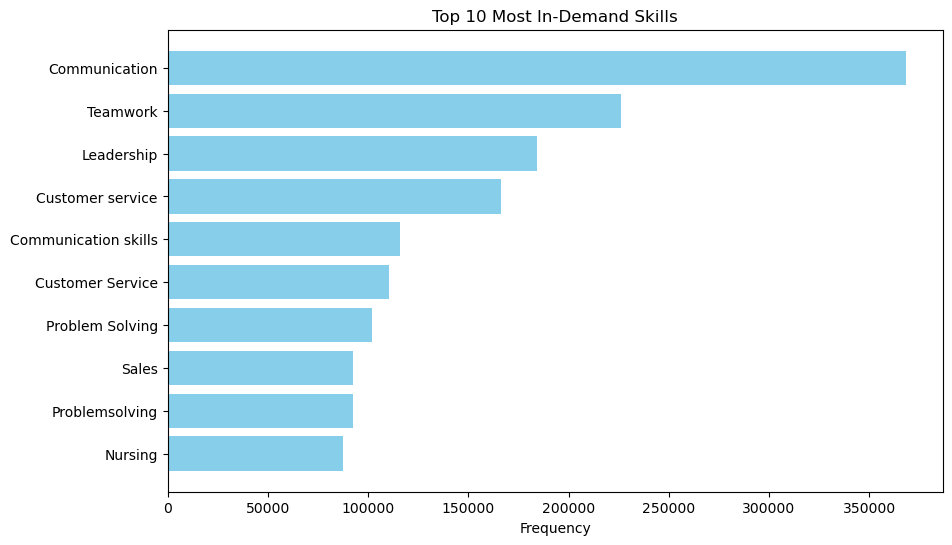

In [4]:
import matplotlib.pyplot as plt

topSkills = skillsSummary.groupBy("skill").sum("count").withColumnRenamed("sum(count)", "total_count") \
    .orderBy("total_count", ascending=False)

topSkillsPd = topSkills.limit(10).toPandas()

plt.figure(figsize=(10,6))
plt.barh(topSkillsPd['skill'], topSkillsPd['total_count'], color="skyblue")
plt.xlabel("Frequency")
plt.title("Top 10 Most In-Demand Skills")
plt.gca().invert_yaxis()
plt.show()



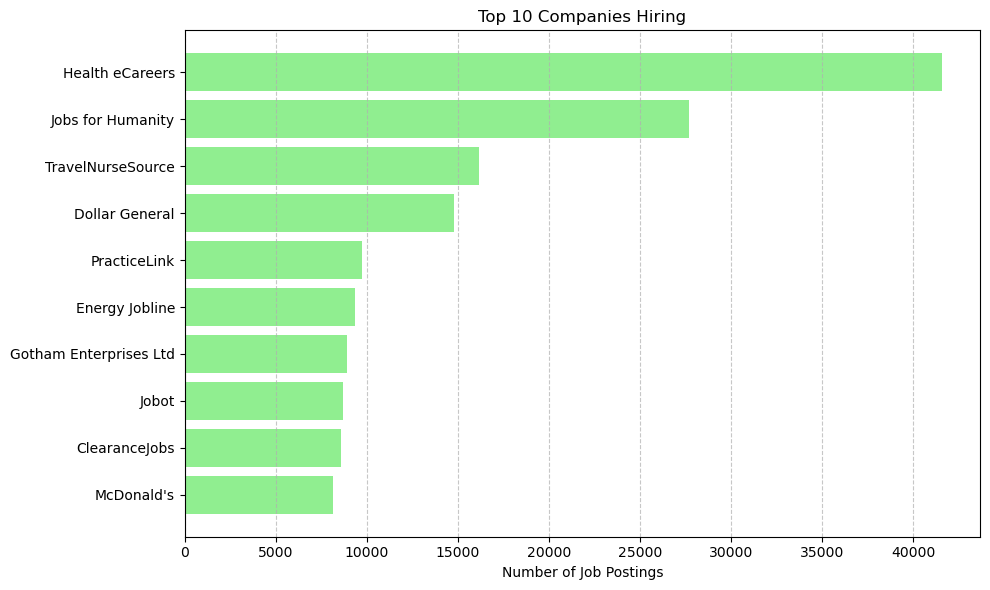

In [5]:
#3.Find the Top Companies Hiring for Different Roles

from pyspark.sql.functions import col, desc

#Missing Value Handling
linkedinJobsC = linkedin_jobs_df.dropna(subset=["company", "job_title", "job_link"])

#outlier handling
linkedinJobsC = linkedinJobsC.filter(
    (col("company").isNotNull()) &
    (col("company") != "") &
    (col("company") != "Unknown")
)

#Aggregation and Grouping - Company and Job Title
companyRoleCounts = linkedinJobsC.groupBy("company", "job_title") \
    .count() \
    .orderBy(desc("count"))

output_path_company_roles = "hdfs://namenode:8020/user/hadoop/EDA_output/top_companies_by_roles/"

companyRoleCounts.write.mode("overwrite").option("header", True).csv(output_path_company_roles)

# Group by company only
topCompanies = linkedinJobsC.groupBy("company") \
    .count() \
    .orderBy(desc("count"))

# Convert to Pandas
topCompaniesPd = topCompanies.limit(10).toPandas()

# Plot
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.barh(topCompaniesPd['company'], topCompaniesPd['count'], color="lightgreen")
plt.xlabel("Number of Job Postings")
plt.title("Top 10 Companies Hiring")
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Company postings saved to: hdfs://namenode:8020/user/hadoop/EDA_output/company_postings/
+----------------------+-----+
|company               |count|
+----------------------+-----+
|Health eCareers       |41597|
|Jobs for Humanity     |27680|
|TravelNurseSource     |16142|
|Dollar General        |14815|
|PracticeLink          |9737 |
|Energy Jobline        |9364 |
|Gotham Enterprises Ltd|8935 |
|Jobot                 |8713 |
|ClearanceJobs         |8599 |
|McDonald's            |8125 |
+----------------------+-----+
only showing top 10 rows



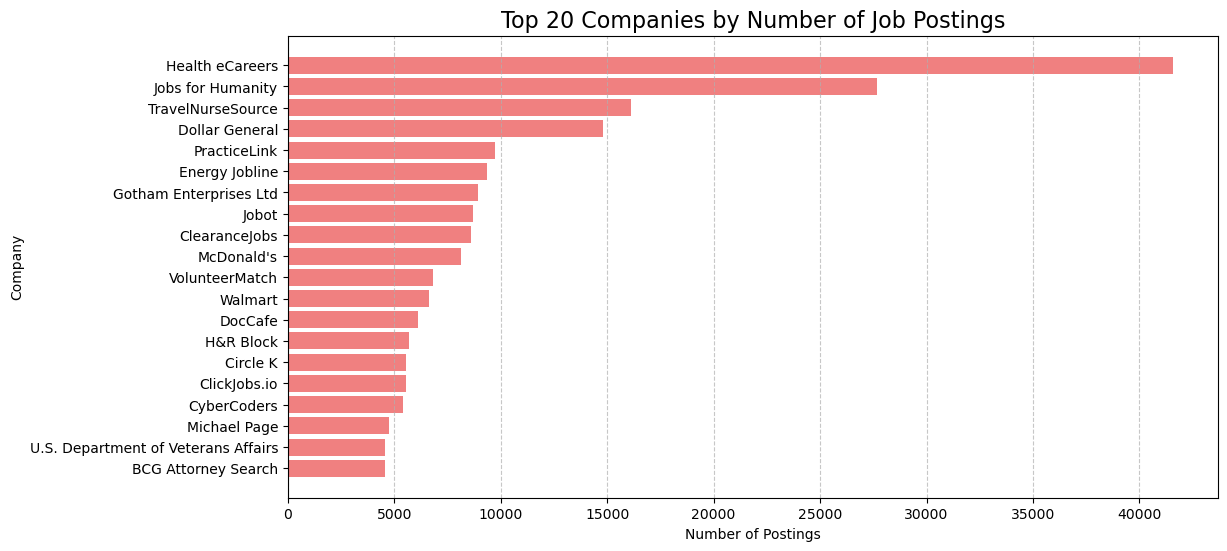

In [3]:
#4.How many postings per company? 

# Missing Value Handling
linkedinJobsC = linkedin_jobs_df.dropna(subset=["company"])

#Outlier Handling
linkedinJobsC = linkedinJobsC.filter(col("company") != "Unknown")

#Aggregation - Count number of postings per company
companyPostings = linkedinJobsC.groupBy("company") \
    .count() \
    .orderBy("count", ascending=False)

op= "hdfs://namenode:8020/user/hadoop/EDA_output/company_postings/"
companyPostings.write.mode("overwrite").option("header", True).csv(op)

print("Company postings saved to:", op)


companyPostings.show(10, truncate=False)

top_companies_pd = companyPostings.limit(20).toPandas()

plt.figure(figsize=(12,6))
plt.barh(top_companies_pd['company'], top_companies_pd['count'], color='lightcoral')
plt.title("Top 20 Companies by Number of Job Postings", fontsize=16)
plt.xlabel("Number of Postings")
plt.ylabel("Company")
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


In [6]:
#5.Compare Job Titles and Their Required Skills
from pyspark.sql.functions import split, explode, col, trim

#Missing Value Handling
jobSkillsC = job_skills_df.dropna(subset=["job_link", "job_skills"])
linkedinJobsC = linkedin_jobs_df.dropna(subset=["job_link", "job_title"])

jobSkillsE = jobSkillsC.withColumn(
    "skill",
    explode(split(col("job_skills"), ","))
).withColumn(
    "skill",
    trim(col("skill"))
)
#outlier handling
jobSkillsE = jobSkillsE.filter(
    (col("skill").isNotNull()) &
    (col("skill") != "") &
    (length(col("skill")) > 2)
)
#Join skills with job titles based on job_link
skillsJobsJoin = jobSkillsE.join(
    linkedinJobsC.select("job_link", "job_title"),
    on="job_link",
    how="inner"
)
#Aggregation and Grouping
skillDistribution = skillsJobsJoin.groupBy("job_title", "skill") \
    .count() \
    .orderBy(col("count").desc())

output_path_skills_jobs = "hdfs://namenode:8020/user/hadoop/EDA_output/job_title_vs_skills/"
skillDistribution.write.mode("overwrite").option("header", True).csv(output_path_skills_jobs)

print(" Job Titles vs Skills saved at:", output_path_skills_jobs)


 Job Titles vs Skills saved at: hdfs://namenode:8020/user/hadoop/EDA_output/job_title_vs_skills/


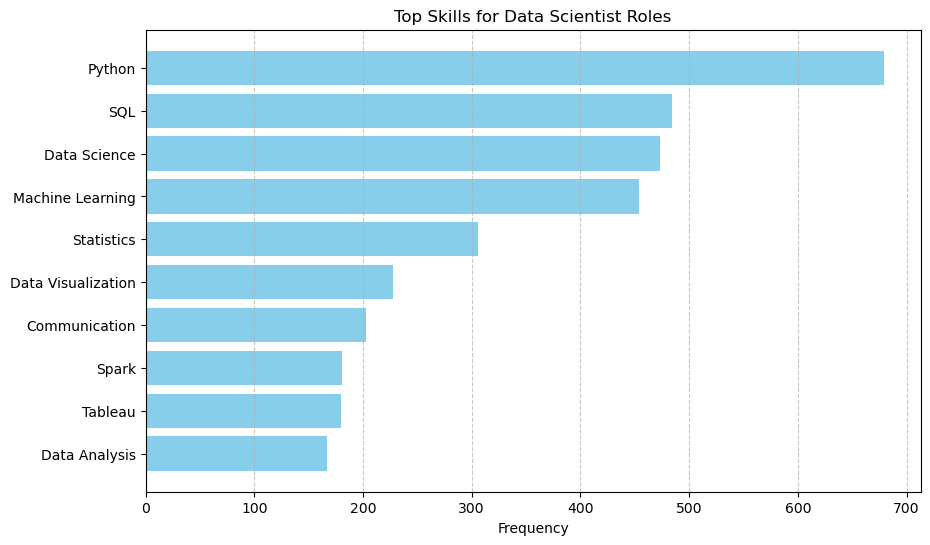

In [7]:
# Filter for a specific job_title
import matplotlib.pyplot as plt

dsSkills = skillsJobsJoin.filter(
    col("job_title").like("%Data Scientist%")
)

# Group and count skills
dsSkillsCount = dsSkills.groupBy("skill").count().orderBy(col("count").desc())

# Convert to Pandas
dsSkillsCount_pd = dsSkillsCount.limit(10).toPandas()

# Plot
plt.figure(figsize=(10,6))
plt.barh(dsSkillsCount_pd['skill'], dsSkillsCount_pd['count'], color='skyblue')
plt.xlabel("Frequency")
plt.title("Top Skills for Data Scientist Roles")
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


In [2]:
pip install pyspark

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.2/317.2 MB 6.2 MB/s eta 0:00:0000:0100:01
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 kB 12.4 MB/s eta 0:00:00
  Created wheel for pyspark: filename=pyspark-3.5.5-py2.py3-none-any.whl size=317747860 sha256=2c135c7c0e50e210485341e3202539f0cdda6e24b3902025bf65e2f6649270ca
  Stored in directory: /home/jovyan/.cache/pip/wheels/0c/7f/b4/0e68c6d8d89d2e582e5498ad88616c16d7c19028680e9d3840
Successfully built pyspark
Note: you may need to restart the kernel to use updated packages.
